In [1]:
library(tidyverse)
library(dplyr)
library(data.table)
library(ggplot2)
library(tidyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose




In [14]:
tb1<-read.delim("/workdir/gfa32/hsct_new/corrected/supp/deconvolution_comparison/tabsap/output_1.tsv")
tb2<-read.delim("/workdir/gfa32/hsct_new/corrected/supp/deconvolution_comparison/tabsap/output_2.tsv")
tb3<-read.delim("/workdir/gfa32/hsct_new/corrected/supp/deconvolution_comparison/tabsap/output_3.tsv")

In [15]:
tb1 <- tb1 %>%
  mutate(sample_id_named = paste0(sample_id, "_tabsap1"))

tb2 <- tb2 %>%
  mutate(sample_id_named = paste0(sample_id, "_tabsap2"))

tb3 <- tb3 %>%
  mutate(sample_id_named = paste0(sample_id, "_tabsap3"))

In [16]:
tb_all<-rbind(tb1, tb2, tb3)

In [17]:
colnames(tb_all) <- gsub("[^A-Za-z0-9]", "_", colnames(tb_all))


In [22]:
tb_all <- tb_all %>%
  mutate(T_cell = CD4_positive_T_cell + CD8_positive_T_cell + innate_like_T_cell + regulatory_T_cell + DN1_thymic_pro_T_cell + DN3_4_thymocyte + DP_thymocyte) %>%
  select(-CD4_positive_T_cell, -CD8_positive_T_cell, -innate_like_T_cell, -regulatory_T_cell, -DN1_thymic_pro_T_cell, -DN3_4_thymocyte, -DP_thymocyte) %>%
  mutate(B_cell = naive_B_cell + memory_B_cell) %>%
  select(-naive_B_cell, -memory_B_cell) %>%
  mutate(monocyte = classical_monocyte + non_classical_monocyte + intermediate_monocyte) %>%
  select(-classical_monocyte, -non_classical_monocyte, -intermediate_monocyte) %>%
  mutate(endothelial_cell = vascular_endothelial_cell + endothelial_cell_of_lymphatic_vessel + endothelial_cell_of_hepatic_sinusoid) %>%
  select(-vascular_endothelial_cell, -endothelial_cell_of_lymphatic_vessel, -endothelial_cell_of_hepatic_sinusoid) %>%
  mutate(platelets = platelet) %>%
  select(-platelet)

In [23]:
library(dplyr)

# Step 1: Select only numeric columns
numeric_df <- tb_all %>%
  select(where(is.numeric))

# Step 2: Compute column means and get top 10
top_10_celltypes <- numeric_df %>%
  summarise(across(everything(), mean, na.rm = TRUE)) %>%
  pivot_longer(everything(), names_to = "cell_type", values_to = "mean_abundance") %>%
  arrange(desc(mean_abundance)) %>%
  slice_head(n = 15)

print(top_10_celltypes)


# A tibble: 15 × 2
   cell_type                         mean_abundance
   <chr>                                      <dbl>
 1 platelets                                0.468  
 2 T_cell                                   0.118  
 3 common_myeloid_progenitor                0.0735 
 4 monocyte                                 0.0670 
 5 B_cell                                   0.0630 
 6 immature_natural_killer_cell             0.0457 
 7 hematopoietic_stem_cell                  0.0408 
 8 cardiac_endothelial_cell                 0.0363 
 9 neutrophil                               0.0302 
10 endothelial_cell                         0.0156 
11 erythrocyte                              0.0137 
12 retinal_neuron                           0.00520
13 pigmented_ciliary_epithelial_cell        0.00329
14 plasmablast                              0.00327
15 Schwann_cell                             0.00304


In [24]:
# Define the non-numeric columns you want to keep
non_numeric_cols <- c("sample_id", "sample_id_named")  # update with your actual metadata column names

# Step 1: Get top 10 numeric columns by average
top_10_cols <- tb_all %>%
  select(where(is.numeric)) %>%
  summarise(across(everything(), mean, na.rm = TRUE)) %>%
  pivot_longer(cols = everything(), names_to = "cell_type", values_to = "mean_val") %>%
  arrange(desc(mean_val)) %>%
  slice_head(n = 15) %>%
  pull(cell_type)

# Step 2: Select the non-numeric + top numeric columns
df_top15_with_meta <- tb_all %>%
  select(all_of(non_numeric_cols), all_of(top_10_cols))


In [ ]:
write.table(tb_all, file = "/tb_all.tsv", sep = "\t", row.names = FALSE, quote = FALSE)
write.table(cg_all, file = "/cg_all.tsv", sep = "\t", row.names = FALSE, quote = FALSE)

In [ ]:
tb_all<-read.delim("/tb_all.tsv")
cg_all<-read.delim("/cg_all.tsv")

In [ ]:
meta<-read.delim("/sample_meta_passQC.tsv")

In [27]:
meta_subset <- meta[, c("sample_id", "timepoint", "sample_group", "Record_ID")]  # pick only the columns you want
merged_tb <- merge(tb_all, meta_subset, by = "sample_id", all.x = TRUE)
merged_cg <- merge(cg_all, meta_subset, by = "sample_id", all.x = TRUE)


In [35]:
merged_tb <- merged_tb %>%
  rename(platelet = platelets)

In [36]:
# Lymphocytes
lymphocyte_decon = c("b_cell","t_cell","plasma_cell","nk_cell","innate_lymphoid_cell")

# Leukocytes
leukocyte_decon = c(lymphocyte_decon,"neutrophil","basophil","mast_cell","macrophage","mature_conventional_dendritic_cell","monocyte")

In [37]:
merged_cg<-merged_cg%>%mutate(lymphocyte=T_cell + B_cell +plasma_cell + natural_killer_cell)
merged_tb<-merged_tb%>%mutate(lymphocyte=T_cell + B_cell +plasma_cell + immature_natural_killer_cell)

In [31]:
library(tidyr)
library(dplyr)
library(purrr)

In [ ]:
# merged <- merged %>%
#   separate(sample_id_named, 
#            into = c("sample_id", "replicate"), 
#            sep = "_tabpsap", 
#            remove = FALSE) %>%
#   mutate(replicate = paste0("tabpsap", replicate))

In [38]:
selected_samples <- c("sample_id", "sample_id_named", "lymphocyte", "monocyte", "neutrophil", "timepoint", "platelet", "erythrocyte", "endothelial_cell", "dendritic_cell", "hematopoietic_stem_cell" )

# Filter for those rows
cg_selected <- merged_cg %>%
  select(all_of(selected_samples))

tb_selected <- merged_tb %>%
  select(all_of(selected_samples))



In [39]:
df_cluster <- rbind(cg_selected, tb_selected)
  # column_to_rownames("sample_id_named")
  # select(where(is.numeric)) 

In [43]:
head(df_cluster)

,sample_id,sample_id_named,T_cell,B_cell,monocyte,neutrophil,timepoint,platelet,erythrocyte,endothelial_cell,dendritic_cell,hematopoietic_stem_cell
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,gvhd_hct_cfrna_1_bp51x51,gvhd_hct_cfrna_1_bp51x51_cxg2,3.238463e-02,3.886701e-02,1.286347e-01,0.13411550,2M,0.4160913,7.227490e-06,0.07925033,6.133678e-05,1.122527e-02
2,gvhd_hct_cfrna_1_bp51x51,gvhd_hct_cfrna_1_bp51x51_cxg1,3.723077e-02,3.849142e-02,1.243988e-01,0.13666266,2M,0.4153368,7.520941e-06,0.08004615,6.351001e-05,1.001478e-02
3,gvhd_hct_cfrna_1_bp51x51,gvhd_hct_cfrna_1_bp51x51_cxg3,3.830553e-02,3.778831e-02,1.267044e-01,0.13682526,2M,0.4114447,7.389572e-06,0.08193826,4.216816e-05,1.061052e-02
4,gvhd_hct_cfrna_100_bp61x61,gvhd_hct_cfrna_100_bp61x61_cxg3,7.056276e-05,5.040836e-05,5.018839e-05,0.02713538,2M,0.3746794,4.285938e-01,0.03162947,1.396742e-05,1.256022e-05
5,gvhd_hct_cfrna_100_bp61x61,gvhd_hct_cfrna_100_bp61x61_cxg1,6.392695e-05,5.074477e-05,5.736874e-05,0.02649449,2M,0.3746444,4.316848e-01,0.03014567,1.757487e-05,1.226502e-05
6,gvhd_hct_cfrna_100_bp61x61,gvhd_hct_cfrna_100_bp61x61_cxg2,6.896732e-05,4.769527e-05,6.432079e-05,0.02576312,2M,0.3802787,4.234380e-01,0.03101585,1.442899e-05,1.141592e-05


In [ ]:
write.table(df_cluster, file = "/combined_output.tsv", sep = "\t", row.names = FALSE, quote = FALSE)

In [23]:
library(dplyr)
library(stringr)

# Step 1: Extract sample_id and replicate
df2 <- df_e %>%
  mutate(
    replicate = str_extract(sample_id_named, "(tabsap|cxg)[123]"),
    sample_id = str_remove(sample_id_named, "_(tabsap|cxg)[123]")
  ) %>%
  select(-sample_id_named)


In [24]:
df2 <- df2 %>%
  mutate(
    reference = case_when(
      str_detect(replicate, "cxg[123]") ~ "cellxgene",
      str_detect(replicate, "tabsap[123]") ~ "tabula_sapiens",
      TRUE ~ NA_character_  # fallback in case of unexpected replicate values
    )
  )

In [ ]:
library(pheatmap)

# Optional: scale across rows or columns
scaled_mat <- scale(as.matrix(cell_fractions[, -1]))  # remove sample_id

# Add sample IDs as rownames
rownames(scaled_mat) <- cell_fractions$sample_id

# Plot heatmap with clustering
pheatmap(
  scaled_mat,
  clustering_distance_rows = "euclidean",
  clustering_distance_cols = "euclidean",
  clustering_method = "complete",
  fontsize_row = 8,
  fontsize_col = 10
)


In [25]:
library(dplyr)
library(tidyr)

# Example: df is your long format dataframe
# Step 1: spread replicate to wide format (replicates as columns)
# wide_df <- df2 %>%
#   pivot_wider(names_from = replicate, values_from = fraction)

data_long <- df2 %>%
  pivot_longer(cols = -c(sample_id, replicate, reference), names_to = "cell_type", values_to = "measurement") %>%
  pivot_wider(names_from = replicate, values_from = measurement, names_prefix = "replicate_")
head(data_long)
# Step 2: Calculate correlation between replicates for each sample_id
correlation_results <- data_long %>%
  group_by(cell_type) %>%
  summarize(
    cor_AB = cor(replicate_tabsap1, replicate_tabsap2, use = "complete.obs", method = "pearson"),
    cor_AC = cor(replicate_tabsap1, replicate_tabsap3, use = "complete.obs", method = "pearson"),
    cor_BC = cor(replicate_tabsap2, replicate_tabsap3, use = "complete.obs", method = "pearson"),
    .groups = "drop"
  )



sample_id,reference,cell_type,replicate_cxg2,replicate_cxg1,replicate_cxg3,replicate_tabsap2,replicate_tabsap1,replicate_tabsap3
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
gvhd_hct_cfrna_1_bp51x51,cellxgene,lymphocyte,1.511510e-01,1.523715e-01,1.530564e-01,NA,NA,NA
gvhd_hct_cfrna_1_bp51x51,cellxgene,monocyte,1.286347e-01,1.243988e-01,1.267044e-01,NA,NA,NA
gvhd_hct_cfrna_1_bp51x51,cellxgene,neutrophil,1.341155e-01,1.366627e-01,1.368253e-01,NA,NA,NA
gvhd_hct_cfrna_1_bp51x51,cellxgene,platelet,4.160913e-01,4.153368e-01,4.114447e-01,NA,NA,NA
gvhd_hct_cfrna_1_bp51x51,cellxgene,erythrocyte,7.227490e-06,7.520941e-06,7.389572e-06,NA,NA,NA
gvhd_hct_cfrna_1_bp51x51,cellxgene,endothelial_cell,7.925033e-02,8.004615e-02,8.193826e-02,NA,NA,NA


In [102]:
head(correlation_results)

cell_type,cor_AB,cor_AC,cor_BC
<chr>,<dbl>,<dbl>,<dbl>
dendritic_cell,0.9915136,0.9931050,0.9955289
endothelial_cell,0.9965766,0.9988974,0.9983725
erythrocyte,0.9603449,0.9652429,0.9997644
hematopoietic_stem_cell,0.9985974,0.9986481,0.9999049
lymphocyte,0.9999140,0.9999328,0.9999612
monocyte,0.9990115,0.9991651,0.9998542


In [26]:
library(dplyr)
library(tidyr)
library(purrr)

# Step 1: Separate replicate from full sample_id column
df_long <- df_e %>%
  mutate(
    replicate = stringr::str_extract(sample_id_named, "tabsap[123]"),
    sample_id = stringr::str_remove(sample_id_named, "_tabsap[123]")
  ) %>%
  select(-sample_id_named) %>%
  pivot_longer(
    cols = -c(sample_id, replicate),
    names_to = "cell_type",
    values_to = "value"
  )

# Step 2: Pivot wider so replicates are columns
df_wide <- df_long %>%
  pivot_wider(
    names_from = replicate,
    values_from = value
  )

# Step 3: Compute correlation across replicates, per sample and cell type
correlation_results <- df_wide %>%
  group_by(sample_id, cell_type) %>%
  summarize(
    cor_AB = cor(tabsap1, tabsap2, use = "complete.obs"),
    cor_AC = cor(tabsap1, tabsap3, use = "complete.obs"),
    cor_BC = cor(tabsap2, tabsap3, use = "complete.obs"),
    cor_mean = mean(c(cor_AB, cor_AC, cor_BC), na.rm = TRUE),
    .groups = "drop"
  )



ERROR: [1m[33mError[39m in `summarize()`:[22m
[1m[22m[36mℹ[39m In argument: `cor_AB = cor(tabsap1, tabsap2, use = "complete.obs")`.
[36mℹ[39m In group 9: `sample_id = "MCC17948_cfRNA_10_bp61x61_cxg1"` `cell_type =
  "dendritic_cell"`.
[1mCaused by error in `cor()`:[22m
[33m![39m no complete element pairs


In [91]:
head(correlation_results)

sample_id,cor_AB,cor_AC,cor_BC,cor_mean
<chr>,"<dbl[,1]>","<dbl[,1]>","<dbl[,1]>",<dbl>
gvhd_hct_cfrna_114_bp61x61,0.9999543,0.9999597,0.9999972,0.9999704
gvhd_hct_cfrna_117_bp61x61,0.9997021,0.9999019,0.9998840,0.9998293
gvhd_hct_cfrna_124_bp61x61,0.9999625,0.9999504,0.9999352,0.9999494
gvhd_hct_cfrna_127_bp61x61,0.9999864,0.9999860,0.9999836,0.9999853
gvhd_hct_cfrna_128_bp61x61,0.9998494,0.9998512,0.9999554,0.9998853
gvhd_hct_cfrna_129_bp61x61,0.9998304,0.9998715,0.9999467,0.9998829


In [27]:
correlation_results <- df_e %>%
  group_by(sample_id) %>%
  nest() %>%  # nest data frame for each sample
  mutate(
    cor_AB = map_dbl(data, ~ cor(.x %>% filter(replicate == "tabpsap1") %>% select(-sample_id, -replicate),
                                 .x %>% filter(replicate == "tabpsap2") %>% select(-sample_id, -replicate),
                                 use = "complete.obs")),
    cor_AC = map_dbl(data, ~ cor(.x %>% filter(replicate == "tabpsap2") %>% select(-sample_id, -replicate),
                                 .x %>% filter(replicate == "tabpsap3") %>% select(-sample_id, -replicate),
                                 use = "complete.obs")),
    cor_BC = map_dbl(data, ~ cor(.x %>% filter(replicate == "tabpsap1") %>% select(-sample_id, -replicate),
                                 .x %>% filter(replicate == "tabpsap3") %>% select(-sample_id, -replicate),
                                 use = "complete.obs"))
  ) %>%
  select(-data) %>%
  mutate(cor_mean = rowMeans(select(., cor_AB, cor_AC, cor_BC), na.rm = TRUE))

ERROR: [1m[33mError[39m in `mutate()`:[22m
[1m[22m[36mℹ[39m In argument: `cor_AB = map_dbl(...)`.
[1mCaused by error in `map_dbl()`:[22m
[1m[22m[36mℹ[39m In index: 1.
[1mCaused by error in `filter()`:[22m
[1m[22m[36mℹ[39m In argument: `replicate == "tabpsap2"`.
[1mCaused by error in `replicate == "tabpsap2"`:[22m
[33m![39m comparison (==) is possible only for atomic and list types


In [2]:
cells<-read.delim("/fs/cbsuvlaminck5/workdir/gfa32/single_cell/subsampled/bayes_output/tabsap/combined_output.tsv")

In [3]:
head(cells)

,sample_id,sample_id_named,T_cell,B_cell,monocyte,neutrophil,timepoint,platelet,erythrocyte,endothelial_cell,dendritic_cell,hematopoietic_stem_cell
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,gvhd_hct_cfrna_1_bp51x51,gvhd_hct_cfrna_1_bp51x51_cxg2,3.228634e-02,4.225851e-02,1.271866e-01,0.13517613,2M,0.3941966,0.004994372,0.07566288,7.911272e-05,1.511754e-02
2,gvhd_hct_cfrna_1_bp51x51,gvhd_hct_cfrna_1_bp51x51_cxg1,4.006346e-02,4.323305e-02,1.086950e-01,0.14066071,2M,0.3825431,0.018975516,0.07558762,2.488556e-04,1.563242e-02
3,gvhd_hct_cfrna_1_bp51x51,gvhd_hct_cfrna_1_bp51x51_cxg3,3.992194e-02,3.858167e-02,1.052808e-01,0.14036721,2M,0.3821164,0.029665215,0.07889693,7.914305e-05,1.678176e-02
4,gvhd_hct_cfrna_100_bp61x61,gvhd_hct_cfrna_100_bp61x61_cxg3,6.366044e-05,2.187059e-05,8.073438e-05,0.03368497,2M,0.4802385,0.182685103,0.03202101,1.154651e-05,1.046804e-05
5,gvhd_hct_cfrna_100_bp61x61,gvhd_hct_cfrna_100_bp61x61_cxg1,8.296761e-05,2.286834e-05,1.102228e-04,0.03284516,2M,0.4732816,0.193181312,0.03047428,1.338691e-05,1.030326e-05
6,gvhd_hct_cfrna_100_bp61x61,gvhd_hct_cfrna_100_bp61x61_cxg2,6.998319e-05,2.325964e-05,8.177814e-05,0.03273255,2M,0.4836708,0.178309205,0.03155515,1.449862e-05,1.095140e-05


In [42]:
# Step 1: Extract sample_id and replicate
df2 <- df_cluster %>%
  mutate(
    replicate = str_extract(sample_id_named, "(tabsap|cxg)[123]"),
    sample_id = str_remove(sample_id_named, "_(tabsap|cxg)[123]")
  ) %>%
  select(-sample_id_named)

In [121]:
head(df_cluster)

,sample_id,sample_id_named,lymphocyte,monocyte,neutrophil,timepoint,platelet,erythrocyte,endothelial_cell,dendritic_cell,hematopoietic_stem_cell
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,gvhd_hct_cfrna_1_bp51x51,gvhd_hct_cfrna_1_bp51x51_cxg2,0.0712516435,1.286347e-01,0.13411550,2M,0.4160913,7.227490e-06,0.07925033,6.133678e-05,1.122527e-02
2,gvhd_hct_cfrna_1_bp51x51,gvhd_hct_cfrna_1_bp51x51_cxg1,0.0757221915,1.243988e-01,0.13666266,2M,0.4153368,7.520941e-06,0.08004615,6.351001e-05,1.001478e-02
3,gvhd_hct_cfrna_1_bp51x51,gvhd_hct_cfrna_1_bp51x51_cxg3,0.0760938433,1.267044e-01,0.13682526,2M,0.4114447,7.389572e-06,0.08193826,4.216816e-05,1.061052e-02
4,gvhd_hct_cfrna_100_bp61x61,gvhd_hct_cfrna_100_bp61x61_cxg3,0.0001209711,5.018839e-05,0.02713538,2M,0.3746794,4.285938e-01,0.03162947,1.396742e-05,1.256022e-05
5,gvhd_hct_cfrna_100_bp61x61,gvhd_hct_cfrna_100_bp61x61_cxg1,0.0001146717,5.736874e-05,0.02649449,2M,0.3746444,4.316848e-01,0.03014567,1.757487e-05,1.226502e-05
6,gvhd_hct_cfrna_100_bp61x61,gvhd_hct_cfrna_100_bp61x61_cxg2,0.0001166626,6.432079e-05,0.02576312,2M,0.3802787,4.234380e-01,0.03101585,1.442899e-05,1.141592e-05


In [43]:
library(tidyr)
library(dplyr)

# Step 1: Convert from wide to long format
df_long <- df2 %>%
  pivot_longer(
    cols = -c(sample_id, replicate, timepoint),
    names_to = "cell_type",
    values_to = "fraction"
  )


In [44]:
df_wide <- df_long %>%
  pivot_wider(names_from = replicate, values_from = fraction)


In [48]:
# Compute Pearson correlation for each method pair and cell type
cor_df <- purrr::map_dfr(method_pairs, function(pair) {
  m1 <- pair[1]
  m2 <- pair[2]

  df_wide %>%
    group_by(cell_type) %>%
    summarise(
      Pearson = cor(.data[[m1]], .data[[m2]], method = "pearson"),
      method1 = m1,
      method2 = m2,
      method_pair = paste(m1, "vs", m2),
      .groups = "drop"
    )
})


In [49]:
head(cor_df)

cell_type,Pearson,method1,method2,method_pair
<chr>,<dbl>,<chr>,<chr>,<chr>
dendritic_cell,0.9593146,cxg1,cxg2,cxg1 vs cxg2
endothelial_cell,0.9997352,cxg1,cxg2,cxg1 vs cxg2
erythrocyte,0.9979421,cxg1,cxg2,cxg1 vs cxg2
hematopoietic_stem_cell,0.9992076,cxg1,cxg2,cxg1 vs cxg2
lymphocyte,0.9998145,cxg1,cxg2,cxg1 vs cxg2
monocyte,0.9981249,cxg1,cxg2,cxg1 vs cxg2


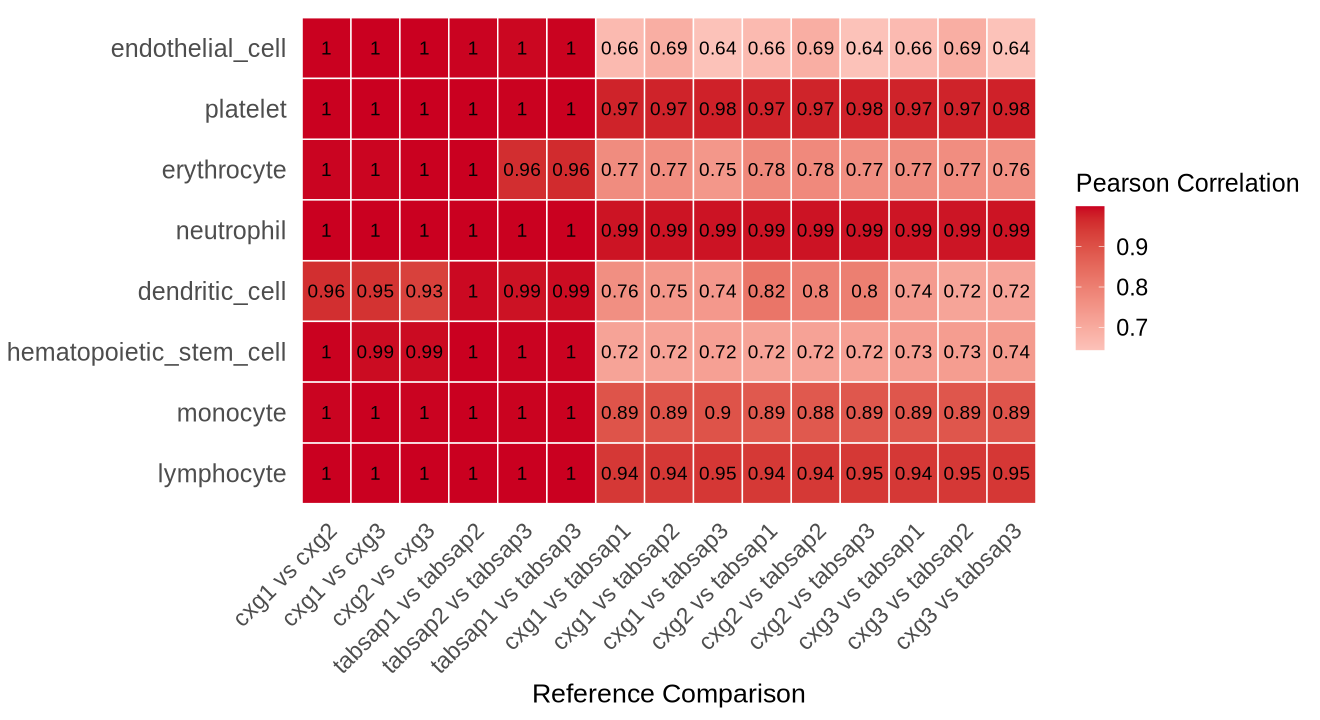

In [51]:
library(ggplot2)

# Optional: specify desired cell_type and method_pair order
# Define desired order for y-axis (cell types)
desired_cell_order <- c("lymphocyte", "monocyte", "hematopoietic_stem_cell", "dendritic_cell", "neutrophil", "erythrocyte", "platelet", "endothelial_cell")

# Define desired order for x-axis (method comparisons)
desired_method_order <- c("cxg1 vs cxg2", "cxg1 vs cxg3", "cxg2 vs cxg3", "tabsap1 vs tabsap2", "tabsap2 vs tabsap3", "tabsap1 vs tabsap3", "cxg1 vs tabsap1", "cxg1 vs tabsap2", "cxg1 vs tabsap3", "cxg2 vs tabsap1", "cxg2 vs tabsap2", "cxg2 vs tabsap3", "cxg3 vs tabsap1", "cxg3 vs tabsap2", "cxg3 vs tabsap3")
# Factor conversion for axis control
cor_df$cell_type <- factor(cor_df$cell_type, levels = desired_cell_order)
cor_df$method_pair <- factor(cor_df$method_pair, levels = desired_method_order)

options(repr.plot.width = 11, repr.plot.height = 6)
# Plot heatmap of Pearson correlation
ggplot(cor_df, aes(x = method_pair, y = cell_type, fill = Pearson)) +
  geom_tile(color = "white", linewidth = 0.4) +
  geom_text(aes(label = round(Pearson, 2)), size = 4, color = "black") +
  scale_fill_gradient2(low = "#0571b0", mid = "white", high = "#ca0020", midpoint = 0.5, name = "Pearson Correlation") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Pearson Correlation Between Deconvolution Tools by Cell Type",
    x = "Reference Comparison",
    y = "Cell Type"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 14),
    axis.text.y = element_text(size = 15),
    axis.title.x = element_text(size = 16),
    axis.title.y = element_blank(),
    plot.title = element_blank(),
    legend.title = element_text(size = 15),
    legend.text = element_text(size = 14),
    panel.grid = element_blank()
  )
ggsave("/workdir/gfa32/hsct_new/corrected/supp/tabsap_cxg_pearson_correlation_heatmap.pdf", width = 11, height = 6)